# Empirical Distribution of a Statistic

The Law of Averages implies that, with high probability, the empirical distribution of a large random sample will resemble the distribution of the population from which the sample was drawn.

This resemblance can often be seen by comparing histograms of a population and a large random sample drawn from it.

As a reminder, below we examine the distribution of departure delays for United Airlines flights and compare it to a random sample of 1,000 flights.

In [1]:
import pandas as pd
%matplotlib inline
path_data = "../../../assets/data/"
import matplotlib.pyplot as plt
plt.style.use("fivethirtyeight")
import numpy as np

In [2]:
united = pd.read_csv(path_data + 'united_summer2015.csv')

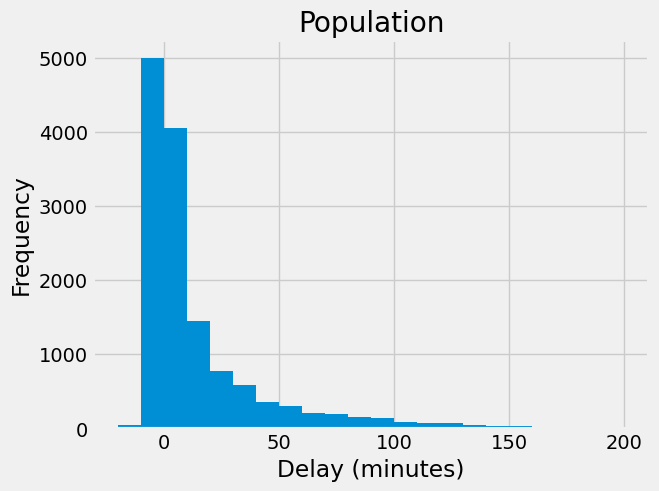

In [3]:
delay_bins = np.arange(-20, 201, 10)
united['Delay'].plot.hist(bins=delay_bins)
plt.title('Population')
plt.xlabel('Delay (minutes)')
plt.show()

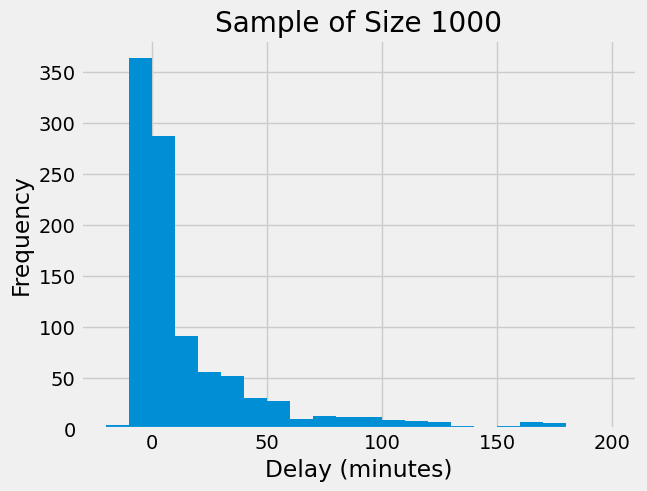

In [4]:
sample_1000 = united.sample(n=1000, replace=True)
sample_1000['Delay'].plot.hist(bins=delay_bins)
plt.title('Sample of Size 1000')
plt.xlabel('Delay (minutes)')
plt.show()

The two histograms clearly resemble one another, though they are not identical.

## Parameter

Frequently, we are interested in numerical quantities associated with a population.

- In a population of voters, what percentage will vote for a candidate?
- In a population of social media users, what is the maximum number of connections?
- In a population of flights, what is the median departure delay?

Numerical quantities associated with a population are called **parameters**. For the population of flights in `united`, we know the value of the population median delay.

In [5]:
np.median(united['Delay'])

np.float64(2.0)

The NumPy function `median` returns the median value of an array or Series. Among all flights in `united`, the median delay was 2 minutes. About half of all flights had delays of 2 minutes or less.

In [6]:
len(united[united['Delay'] <= 2]) / len(united)

0.5018444846292948

Half of all flights left no more than 2 minutes after their scheduled departure time.

**Note:** The proportion is not exactly 50% because many flights had delays of exactly 2 minutes. These ties are common in real datasets.

In [7]:
len(united[united['Delay'] == 2])

480

## Statistic

In many situations, we are interested in estimating an unknown parameter using data from a random sample.

A **statistic** is any numerical quantity computed from a sample. The sample median is therefore a statistic.

Recall that `sample_1000` contains a random sample of 1,000 flights. The observed sample median is:

In [8]:
np.median(sample_1000['Delay'])

np.float64(2.0)

Our sample produced one observed value of the statistic. However, the sample could have been different, and therefore the statistic could have been different as well.

In [9]:
np.median(united.sample(n=1000, replace=True)['Delay'])

np.float64(2.0)

Run the cell several times to see how the value changes. Often it equals 2, the population median, but sometimes it differs.

**Just how different could the statistic have been?** To answer this question, we can simulate the statistic many times and examine its distribution.

## Simulating a Statistic

We will simulate the sample median for samples of size 1,000.

**Step 1:** Decide which statistic to simulate.

We will simulate the median of a random sample of 1,000 flight delays.

**Step 2:** Define a function that returns one simulated value of the statistic.

In [10]:
def random_sample_median():
    return np.median(united.sample(n=1000, replace=True)["Delay"])

**Step 3:** Decide how many simulated values to generate.

We will perform 5,000 repetitions.

**Step 4:** Use a loop to generate and collect the simulated values.

In [11]:
medians = np.array([])

for i in np.arange(5000):
    medians = np.append(medians, random_sample_median())

The simulation is complete. All 5,000 simulated sample medians have been stored in the array `medians`.

## Visualization

Here are the simulated sample medians in a pandas DataFrame.

In [12]:
simulated_medians = pd.DataFrame({'Sample Median': medians})
simulated_medians

,Sample Median
0,4.0
1,2.0
2,3.0
3,2.0
4,3.0
...,...
4995,3.0
4996,1.0
4997,2.0
4998,2.0


We can visualize the simulated values using a histogram. This histogram is an **empirical histogram of the statistic** and displays the **empirical distribution** of the statistic.

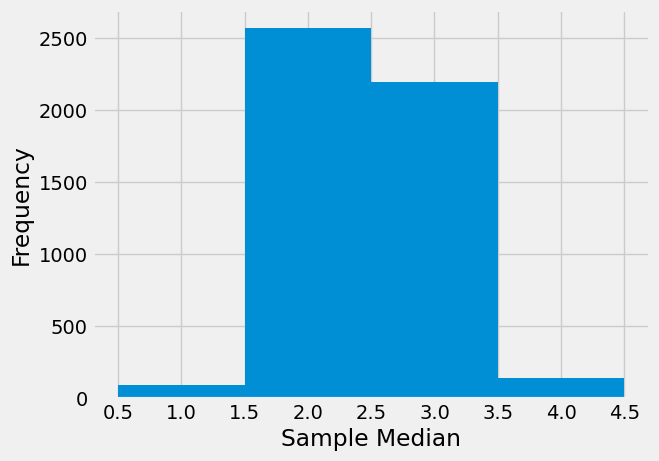

In [13]:
simulated_medians['Sample Median'].plot.hist(bins=np.arange(0.5, 5, 1))
plt.xlabel('Sample Median')
plt.show()

The sample median is very likely to be close to 2, which is the value of the population median. Since samples of 1,000 flights tend to resemble the population, their median delays tend to be close to the population median.

This illustrates how a statistic can provide a useful estimate of a population parameter.

## The Power of Simulation

If we could generate every possible random sample of size 1,000, we would know the complete probability distribution of the sample median. However, the number of possible samples is generally far too large to enumerate, and exact probability calculations can be extremely difficult.

This is where simulation becomes valuable.

By the Law of Averages, the empirical distribution generated from many repeated simulations is likely to resemble the true probability distribution of the statistic. As a result, simulation allows us to approximate probability distributions without deriving them mathematically or generating every possible sample.

Simulation is therefore one of the most powerful tools in data science for understanding the behavior of random quantities.